# 5 · Magnitude sum: bSSFP contrast without banding

The complex sum of notebook 4 keeps the off-resonance phase of every echo, and with it the bands.
The echo *magnitudes* carry no off-resonance at all (Eq. 4a). The paper therefore sums magnitudes,
restores the known polarity of the negative orders (Eq. 2) and keeps the virtual phase cycle
(Eq. 7):

$$
M_{\Sigma|\cdot|}(\Delta\phi)=\sum_{k=k_1}^{k_N}|S_k|\,e^{i\{k\Delta\phi+[u(k)-1]\pi\}} .
$$

In the infinite-order limit (SI Eq. S4.4) this is the geometric-series form of bSSFP from
notebook 4 with $\theta_\text{TE}=0$ and $\theta_\text{TR}=\Delta\phi$, i.e. $M_{\Sigma|\cdot|}(\Delta\phi)=M_\infty(0,\Delta\phi)$:
bSSFP contrast at $\theta_\text{TR}=\Delta\phi$ **in every voxel, whatever its off-resonance**. No voxel can fall into
a band, and $\Delta\phi$ becomes a contrast setting that is chosen after the scan.

The data are those of notebook 4 (one MESS scan, 24 phase-cycled bSSFP scans), loaded from
`.cache/`.

In [1]:
import sys
import warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore", module="cupy|sigpy")

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_erosion
import mess
from mess import magnitude_sum, plotting, simulation as sim, theory

plotting.use_style()
CACHE = ".cache"
N_DUMMY = 2000                                    # see notebook 2

protocol = mess.MESS2D(orders=(2, -3), flip_angle=50)
bssfp = protocol.bssfp()
phantom = sim.brain_phantom(150)
cycles = np.deg2rad(np.arange(0, 360, 15))

S = sim.reconstruct(sim.simulate(protocol.make_sequence(phase_cycle=0.0, n_dummy=N_DUMMY),
                                 phantom, CACHE), protocol)
M_bssfp = np.stack([sim.reconstruct(sim.simulate(bssfp.make_sequence(phase_cycle=psi, n_dummy=N_DUMMY),
                                                 phantom, CACHE), bssfp)[0] for psi in cycles])
M_mag = magnitude_sum(S, protocol.orders, cycles)            # Eq. 7, one image per Δφ

## Sweeping the phase cycle

Same layout as in notebook 4. The magnitude sum (□, dashed: Eq. 7 with six orders) follows the
bSSFP profile of its tissue at $\theta_\text{TR}=\Delta\phi$, and the whole image does so at once.

In [2]:
def on_resonance_voxel(name):
    inside = binary_erosion(phantom.mask(name), iterations=2)
    return np.unravel_index(np.argmin(np.where(inside, np.abs(phantom.off_resonance), np.inf)),
                            inside.shape)

rois = {name: on_resonance_voxel(name) for name in ("WM", "GM", "CSF")}
dense = np.linspace(0, 2 * np.pi, 361)
curves, roi_values = [], {}
for name, (ix, iy) in rois.items():
    _, t1, t2, t2p = sim.TABLE_S1[name]
    color = plotting.TISSUE_COLORS[name]
    curves.append(dict(x=dense, y=np.abs(theory.m_bssfp(protocol.te0, 50, protocol.tr, t1, t2, t2p,
                                                       2 * np.pi * phantom.off_resonance[ix, iy], dense)),
                       color=color, label=f"{name}  bSSFP, Eq. 5", direct_label=name))
    model = theory.mess_echoes(protocol.orders, protocol.te0, protocol.delta_te, 50, protocol.tr,
                               t1, t2, t2p)
    curves.append(dict(x=dense, y=np.abs(magnitude_sum(model, protocol.orders, dense)), color=color,
                       ls="--", lw=1.1, label=f"{name}  $M_{{\\Sigma|\\cdot|}}$, Eq. 7"))
    roi_values[name] = (np.abs(M_bssfp[:, ix, iy]) / phantom.pd[ix, iy],
                        np.abs(M_mag[:, ix, iy]) / phantom.pd[ix, iy])

tissue = phantom.mask("WM") | phantom.mask("GM")
vmax = 2.5 * np.median(np.abs(M_bssfp[12])[tissue])
fig, anim = plotting.phase_cycle_animation(
    cycles, np.abs(M_bssfp), np.abs(M_mag),
    left_title=lambda d: f"bSSFP  $M_\\mathrm{{bSSFP}}$,  $\\Delta\\psi$ = {d:.0f}°",
    right_title=lambda d: f"MESS magnitude sum  $M_{{\\Sigma|\\cdot|}}$,  $\\Delta\\phi$ = {d:.0f}°",
    curves=curves, rois=rois, roi_values=roi_values, vmax=vmax,
    legend=("bSSFP, Eq. 5", "magnitude sum $M_{\\Sigma|\\cdot|}$, Eq. 7",
            "simulated bSSFP", "simulated $M_{\\Sigma|\\cdot|}$"),
    xlabel="RF phase cycle $\\Delta\\psi$ (bSSFP)  =  virtual phase cycle $\\Delta\\phi$ (MESS)",
    path="figures/magnitude_sum.gif")
plt.close(fig)

![bSSFP phase cycling and the MESS magnitude sum](figures/magnitude_sum.gif)

While the bands of bSSFP sweep through the brain, the magnitude-sum image stays free of them: it
changes only its contrast, in step with the profile at the cursor.

How uniform is each image? The spread of the WM signal over the brain (robust coefficient of
variation, interquartile range over median):

In [3]:
wm = binary_erosion(phantom.mask("WM"), iterations=1)
def spread(images):
    values = np.abs(images)[:, wm] / phantom.pd[wm]
    q1, q2, q3 = np.percentile(values, [25, 50, 75], axis=1)
    return (q3 - q1) / q2
for label, stack in (("bSSFP", M_bssfp), ("magnitude sum", M_mag)):
    s = spread(stack)
    print(f"{label:14s} WM spread over the 24 phase cycles: median {100 * np.median(s):5.1f} %,"
          f"  worst {100 * s.max():5.1f} %")

bSSFP          WM spread over the 24 phase cycles: median  42.7 %,  worst 109.2 %
magnitude sum  WM spread over the 24 phase cycles: median   0.7 %,  worst   0.7 %


## Retrospective contrast tuning

Because $\Delta\phi$ is applied in reconstruction, one scan yields a whole family of contrasts
(Fig. 8 of the paper). Below, tissue signals of the magnitude sum against $\Delta\phi$ (lines:
Eq. 7; markers: median over each tissue in the simulation), the WM–CSF contrast, and four images.

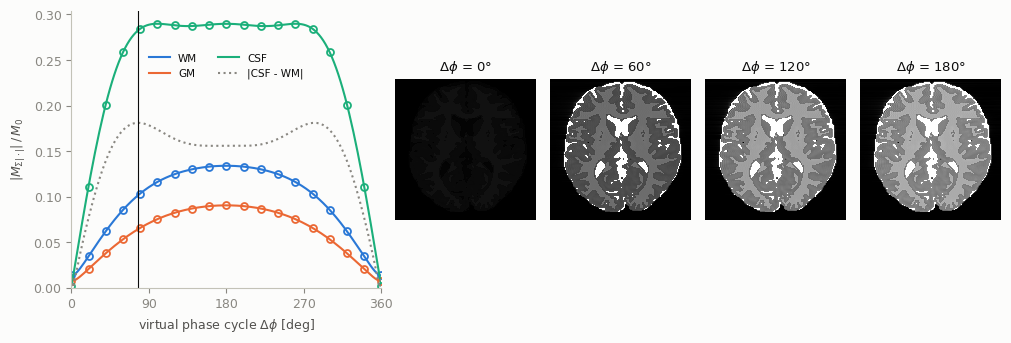

largest WM-CSF contrast in [0, 180] deg at dphi = 78 deg


In [4]:
fine = np.linspace(0, 2 * np.pi, 145)
M_fine = magnitude_sum(S, protocol.orders, fine)
fig = plt.figure(figsize=(12, 3.6))
grid = fig.add_gridspec(1, 5, width_ratios=[2.2, 1, 1, 1, 1], wspace=0.08)
ax = fig.add_subplot(grid[0])
signal = {}
for name in ("WM", "GM", "CSF"):
    m = binary_erosion(phantom.mask(name), iterations=2)
    _, t1, t2, t2p = sim.TABLE_S1[name]
    model = theory.mess_echoes(protocol.orders, protocol.te0, protocol.delta_te, 50, protocol.tr,
                               t1, t2, t2p)
    signal[name] = np.abs(magnitude_sum(model, protocol.orders, fine))
    measured = np.median(np.abs(M_fine[:, m]) / phantom.pd[m], axis=1)
    color = plotting.TISSUE_COLORS[name]
    ax.plot(np.rad2deg(fine), signal[name], color=color, label=name)
    ax.plot(np.rad2deg(fine[::8]), measured[::8], "o", ms=5, mfc="none", mec=color, mew=1.3)
contrast = np.abs(signal["CSF"] - signal["WM"])
best = fine[np.argmax(contrast[fine <= np.pi])]
ax.plot(np.rad2deg(fine), contrast, color=plotting.MUTED, ls=":", label="|CSF - WM|")
ax.axvline(np.rad2deg(best), color=plotting.INK, lw=0.8)
ax.set_xlim(0, 360)
ax.set_xticks(np.arange(0, 361, 90))
ax.set_xlabel("virtual phase cycle $\\Delta\\phi$ [deg]")
ax.set_ylabel("$|M_{\\Sigma|\\cdot|}|\\,/\\,M_0$")
ax.set_ylim(bottom=0)
ax.legend(fontsize=7.5, ncol=2, loc="center", bbox_to_anchor=(0.5, 0.8))
for c, d in enumerate((0, 60, 120, 180)):
    plotting.show(fig.add_subplot(grid[c + 1]), np.abs(magnitude_sum(S, protocol.orders, np.deg2rad(d))),
                  vmax=vmax, title=f"$\\Delta\\phi$ = {d}°")
plt.show()
print(f"largest WM-CSF contrast in [0, 180] deg at dphi = {np.rad2deg(best):.0f} deg")

## Six orders versus the two DESS orders

The same magnitude sum over only $k\in[0,-1]$ is the DESS-equivalent reconstruction of the paper.
Two orders give a half-sine-like $\Delta\phi$ dependence instead of the bSSFP-like profile of six orders,
which limits how far the contrast can be tuned (Fig. 9 of the paper).

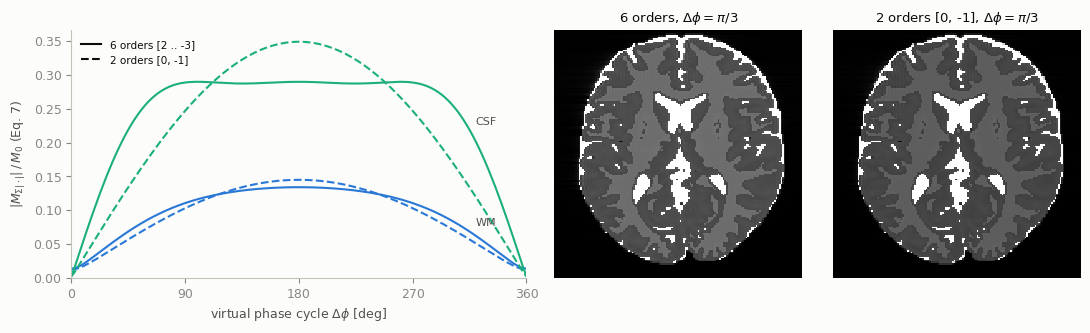

In [5]:
index = {k: j for j, k in enumerate(protocol.orders)}
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), gridspec_kw=dict(width_ratios=[1.8, 1, 1]))
for name in ("WM", "CSF"):
    _, t1, t2, t2p = sim.TABLE_S1[name]
    model = theory.mess_echoes(protocol.orders, protocol.te0, protocol.delta_te, 50, protocol.tr,
                               t1, t2, t2p)
    color = plotting.TISSUE_COLORS[name]
    six = np.abs(magnitude_sum(model, protocol.orders, fine))
    axes[0].plot(np.rad2deg(fine), six, color=color)
    axes[0].plot(np.rad2deg(fine), np.abs(magnitude_sum(model[[index[0], index[-1]]], [0, -1], fine)),
                 color=color, ls="--")
    axes[0].annotate(name, (315, six[np.argmin(np.abs(np.rad2deg(fine) - 315))]), xytext=(4, 4),
                     textcoords="offset points", color=plotting.INK_SECONDARY, fontsize=8)
axes[0].set_xlim(0, 360)
axes[0].set_xticks(np.arange(0, 361, 90))
axes[0].set_xlabel("virtual phase cycle $\\Delta\\phi$ [deg]")
axes[0].set_ylabel("$|M_{\\Sigma|\\cdot|}|\\,/\\,M_0$ (Eq. 7)")
axes[0].set_ylim(bottom=0)
axes[0].legend(handles=[plt.Line2D([], [], color=plotting.INK, label="6 orders [2 .. -3]"),
                        plt.Line2D([], [], color=plotting.INK, ls="--", label="2 orders [0, -1]")],
               fontsize=7.5, loc="upper left")
d = np.pi / 3
plotting.show(axes[1], np.abs(magnitude_sum(S, protocol.orders, d)), vmax=vmax,
              title="6 orders, $\\Delta\\phi=\\pi/3$")
plotting.show(axes[2], np.abs(magnitude_sum(S[[index[0], index[-1]]], [0, -1], d)), vmax=vmax,
              title="2 orders [0, -1], $\\Delta\\phi=\\pi/3$")
fig.tight_layout()
plt.show()

## Summary

* One MESS scan contains the individual SSFP orders $S_k$ (notebook 3).
* Their **complex sum** reproduces phase-cycled bSSFP, bands included, with the virtual phase cycle
  $\Delta\phi$ in the role of $\Delta\psi$ (notebook 4).
* Their **magnitude sum** gives bSSFP-like contrast without any banding, and $\Delta\phi$ tunes that
  contrast after the scan.

Both sums add the noise of $N$ echoes: relative to bSSFP the SNR scales as $1/\sqrt{N}$ for the complex
sum and $1/\sqrt{N/2}$ for the magnitude sum (Eq. 9 and SI S5 of the paper). The simulations here
are noise-free. The real scans of the paper used the 3D protocol of notebook 1:
`examples/write_3d_sequences.py` writes it to `seq/3d/paper/`, and `examples/write_2d_sequences.py`
writes the 2D sequences simulated here to `seq/2d/`.